In [43]:
import pandas as pd
pdf=pd.read_csv("C:\\Users\\chandini ch\\Downloads\\customer_data_for_clustering.csv")
print(pdf)

      age  income  budget                 ph_no  \
0      39  106742   95864         (916)369-2281   
1      49  118622   72831   +1-369-485-5317x056   
2      70  198750  110988      811-873-9259x188   
3      68  209593   93283          995.283.9371   
4      61  162339   65754    698-681-1310x61051   
...   ...     ...     ...                   ...   
9995   27  204950   94472         (245)370-8326   
9996   42  136611  119298  001-830-629-6931x002   
9997   52  135582  108996  001-529-646-0765x840   
9998   56  170496  129964       +1-266-793-1194   
9999   67  242598  181443       +1-387-832-0315   

                              mail_id rented_house insurance   occupation  
0                  yclark@example.com           No        No  Electrician  
1          tracydavenport@example.com          Yes        No  Salesperson  
2          suzanneroberts@example.net          Yes       Yes   Consultant  
3                abennett@example.org           No       Yes        Nurse  
4      

In [4]:
pdf.isna().sum()

age                0
income             0
budget             0
ph_no            962
mail_id         1033
rented_house       0
insurance          0
occupation         0
dtype: int64

In [5]:
pdf.dropna(inplace=True)

In [42]:
pdf.isna().sum()

age                   0
income                0
budget                0
ph_no               962
mail_id            1033
rented_house          0
insurance             0
occupation            0
rented_house_le       0
insurance_le          0
occupation_le         0
dtype: int64

In [41]:
pdf.shape


(10000, 11)

In [40]:
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              10000 non-null  int64
 1   income           10000 non-null  int64
 2   budget           10000 non-null  int64
 3   ph_no            9038 non-null   str  
 4   mail_id          8967 non-null   str  
 5   rented_house     10000 non-null  str  
 6   insurance        10000 non-null  str  
 7   occupation       10000 non-null  str  
 8   rented_house_le  10000 non-null  int64
 9   insurance_le     10000 non-null  int64
 10  occupation_le    10000 non-null  int64
dtypes: int64(6), str(5)
memory usage: 859.5 KB


In [39]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
pdf["rented_house_le"]=le.fit_transform(pdf["rented_house"])

In [38]:
pdf["insurance_le"]=le.fit_transform(pdf["insurance"])

In [37]:
pdf["occupation_le"]=le.fit_transform(pdf["occupation"])

In [34]:
pdf_le=pdf[["age","income","budget","rented_house_le","insurance_le","occupation_le"]]

In [35]:
pdf_le.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              10000 non-null  int64
 1   income           10000 non-null  int64
 2   budget           10000 non-null  int64
 3   rented_house_le  10000 non-null  int64
 4   insurance_le     10000 non-null  int64
 5   occupation_le    10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pdf_le)
print(X_scaled)

[[-0.3211607  -1.10484052 -0.15865908 ... -0.99203175 -0.25035202
   1.29218675]
 [ 0.33132645 -0.86944855 -0.7567063  ... -0.99203175  1.13385987
   1.29218675]
 [ 1.70154945  0.7182188   0.23403254 ...  1.00803226 -0.76943149
  -0.03927822]
 ...
 [ 0.52707259 -0.53340075  0.18231066 ... -0.99203175  1.65293934
  -1.37074319]
 [ 0.78806745  0.15839011  0.72674057 ... -0.99203175 -0.42337851
   0.62645427]
 [ 1.50580331  1.58702918  2.06338247 ...  1.00803226  0.61478041
  -0.7050107 ]]


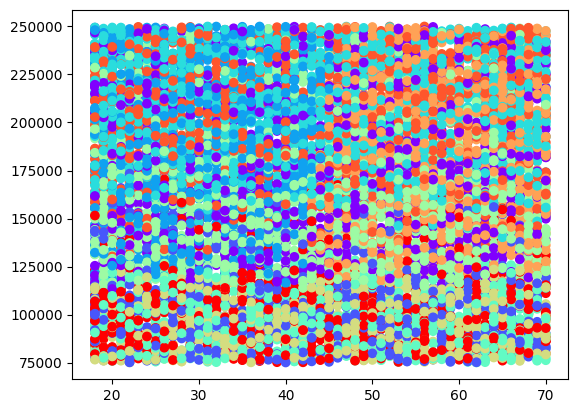

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
km=KMeans(n_clusters=10,random_state=50)
km.fit(X_scaled)
pdf_le["cluster"]=km.labels_
plt.scatter(pdf_le["age"],pdf_le["income"],c=pdf_le["cluster"],cmap="rainbow")

In [14]:
from sklearn.metrics import silhouette_score
from sklearn .cluster import KMeans
x=pdf_le
wcss=[]
silhouette_scores=[]
for i in range(2,11):
    km1=KMeans(n_clusters=i,random_state=50)
    labels=km1.fit_predict(x)
    wcss.append(km1.inertia_)
    silhouette_scores.append(silhouette_score(x,labels))

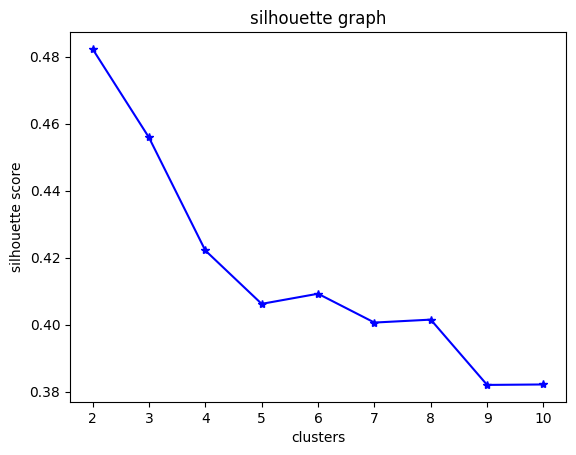

In [40]:
plt.plot(range(2,11),silhouette_scores,'b*-')
plt.title("silhouette graph")
plt.xlabel("clusters")
plt.ylabel("silhouette score")
plt.show()

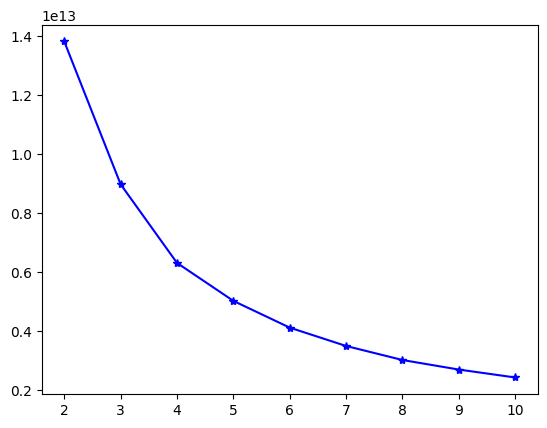

In [35]:
plt.plot(range(2,11),wcss,'b*-')
plt.show()

In [50]:
import matplotlib.pyplot as plt
corr = pdf_le["income"].corr(pdf_le["budget"])
print(corr)

0.5190073242957391


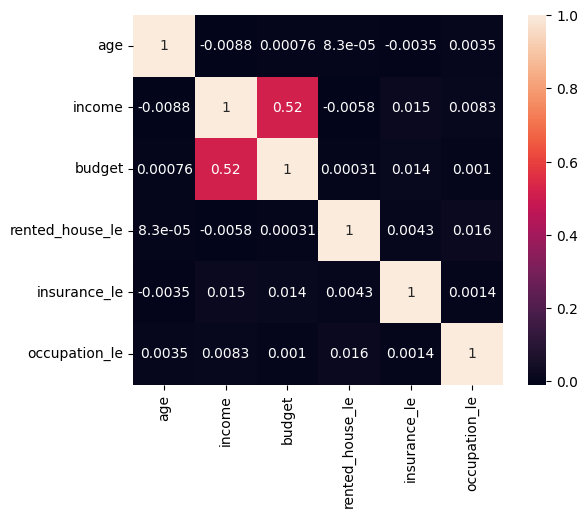

In [56]:
import seaborn as sns 
sns.heatmap(pdf_le.corr(),annot=True)
plt.imshow(pdf_le.corr(),cmap=plt.cm.GnBu,
           interpolation='nearest',
           data=True)